In [63]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [64]:
df = pd.read_csv("Hastalar.csv")
df = df.dropna()
df

,Hasta_ID,Yaş,BKİ,Günlük_Adım_Sayısı,Sistolik_Tansiyon,Diyastolik_Tansiyon
0,1001,69,29.5,12870,151,83
1,1002,32,30.3,10678,129,72
2,1003,78,27.3,5082,156,79
3,1004,38,24.2,14718,118,73
4,1005,41,28.4,5183,136,74
...,...,...,...,...,...,...
1995,2996,19,29.8,3606,120,69
1996,2997,46,26.0,8846,132,79
1997,2998,69,31.6,9643,152,84
1998,2999,44,20.8,7432,126,70


In [65]:
df["sistolik_risk"] = df["Sistolik_Tansiyon"].apply(lambda x: 1 if x > 120 else 0 )

In [66]:
df["diyastolik_risk"] = df["Diyastolik_Tansiyon"].apply(lambda x: 1 if x > 80 else 0 )

In [67]:
df["risk_seviye"] = df["sistolik_risk"] + df["diyastolik_risk"]

In [70]:
x = df[["Yaş","BKİ","Günlük_Adım_Sayısı"]]
y = df["risk_seviye"]

In [71]:
x

,Yaş,BKİ,Günlük_Adım_Sayısı
0,69,29.5,12870
1,32,30.3,10678
2,78,27.3,5082
3,38,24.2,14718
4,41,28.4,5183
...,...,...,...
1995,19,29.8,3606
1996,46,26.0,8846
1997,69,31.6,9643
1998,44,20.8,7432


In [72]:
x_train, x_test, y_train, y_test = train_test_split(x,y,
                                                    test_size = 0.25,
                                                    random_state = 42)

In [73]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [74]:
knn_model = KNeighborsClassifier().fit(x_train_scaled, y_train)
loj_model = LogisticRegression().fit(x_train_scaled, y_train)
svm_model = SVC().fit(x_train_scaled, y_train)
mlpc_model = MLPClassifier().fit(x_train_scaled, y_train)
cart_model = DecisionTreeClassifier().fit(x_train_scaled, y_train)
rf_model = RandomForestClassifier().fit(x_train_scaled, y_train)
gbm_model = GradientBoostingClassifier().fit(x_train_scaled, y_train)
xgb_model = XGBClassifier().fit(x_train_scaled, y_train)
lgbm_model = LGBMClassifier().fit(x_train_scaled, y_train)
catb_model = CatBoostClassifier().fit(x_train_scaled, y_train, verbose = False)

C:\Users\Yakub\PyCharmMiscProject\tensorvenv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000022 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 1500, number of used features: 3
[LightGBM] [Info] Start training from score -2.109214
[LightGBM] [Info] Start training from score -0.485591
[LightGBM] [Info] Start training from score -1.334335
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [75]:
modeller = [
    knn_model,
    loj_model,
    svm_model,
    mlpc_model,
    cart_model,
    rf_model,
    gbm_model,
    catb_model,
    lgbm_model,
    xgb_model]

sonuc = []
sonuclar = pd.DataFrame(columns= ["Modeller","Accuracy"])

for model in modeller:
    isimler = model.__class__.__name__
    y_pred = model.predict(x_test_scaled)
    dogruluk = accuracy_score(y_test, y_pred)
    sonuc = pd.DataFrame([[isimler, dogruluk * 100]], columns= ["Modeller","Accuracy"])
    sonuclar = pd.concat([sonuclar, sonuc], ignore_index=True)

C:\Users\Yakub\PyCharmMiscProject\tensorvenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


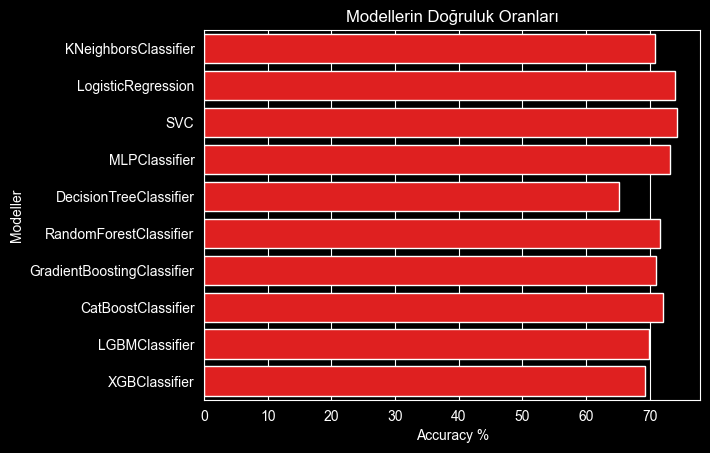

In [76]:
sns.barplot(x= 'Accuracy', y = 'Modeller', data=sonuclar, color="r")
plt.xlabel('Accuracy %')
plt.title('Modellerin Doğruluk Oranları');

In [77]:
sonuclar

,Modeller,Accuracy
0,KNeighborsClassifier,70.8
1,LogisticRegression,74.0
2,SVC,74.2
3,MLPClassifier,73.2
4,DecisionTreeClassifier,65.2
5,RandomForestClassifier,71.6
6,GradientBoostingClassifier,71.0
7,CatBoostClassifier,72.0
8,LGBMClassifier,69.8
9,XGBClassifier,69.2


In [78]:
svm_params = [
    {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": ["scale", "auto",0.1, 1]},]
svm_cv_model = GridSearchCV(svm_model, svm_params, cv=5,  n_jobs=-1, verbose=2).fit(x_train_scaled, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [79]:
svm_cv_model.best_params_

{'C': 100, 'kernel': 'linear'}

In [80]:
svm_tuned = SVC(kernel = 'linear').fit(x_train_scaled, y_train)

In [81]:
y_pred = svm_tuned.predict(x_test_scaled)

In [82]:
accuracy_score(y_test, y_pred)

0.748